data loading and converting it to csv file

In [45]:
import sys
import os
%load_ext autoreload
%autoreload 2
# Tell the notebook where to find your 'src' folder
sys.path.append(os.path.abspath('../'))
from src.data_loader import  load_data
from src.eda_utils import cast_columns, pre_eda_profile, handle_missing_values
from src.visualizations import (
    prepare_plotting_data,
    plot_univariate_distributions,
    plot_premium_vs_claims,
    plot_province_risk,
    plot_outliers,
    plot_loss_ratio,
    plot_temporal_trends,
    plot_vehicle_claims
)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
#load file to pd dataframe
raw_df = load_data()


c:\Users\Hermela\Desktop\10academy\week3\src\data_loader.py:10: DtypeWarning: Columns (0: Citizenship, 1: CapitalOutstanding, 2: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Data Summarization

In [3]:
raw_df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [4]:
# Cast columns to correct dtypes before profiling.
df = cast_columns(raw_df)


In [5]:
#analyze the cleaned structure
missing_report = pre_eda_profile(df)


1. DTYPE SUMMARY

  NUMERIC (FLOAT64) (10)
    • cubiccapacity
    • kilowatts
    • CustomValueEstimate
    • CapitalOutstanding
    • NumberOfVehiclesInFleet
    • SumInsured
    • CalculatedPremiumPerTerm
    • ExcessSelected
    • TotalPremium
    • TotalClaims

  NUMERIC (NULLABLE INT) (3)
    • RegistrationYear
    • Cylinders
    • NumberOfDoors

  BOOLEAN (NULLABLE) (7)
    • IsVATRegistered
    • AlarmImmobiliser
    • TrackingDevice
    • WrittenOff
    • Rebuilt
    • Converted
    • CrossBorder

  CATEGORICAL (26)
    • Citizenship
    • LegalType
    • Title
    • Language
    • Bank
    • AccountType
    • MaritalStatus
    • Gender
    • Country
    • Province
    • MainCrestaZone
    • SubCrestaZone
    • ItemType
    • VehicleType
    • make
    • Model
    • bodytype
    • NewVehicle
    • TermFrequency
    • CoverCategory
    • CoverType
    • CoverGroup
    • Section
    • Product
    • StatutoryClass
    • StatutoryRiskType

  STRING (4)
    • UnderwrittenCoverID
 

 Data Quality Assessment 

In [11]:
missing_report.sort_values("pct", ascending=False).head(15)

,missing,pct
NumberOfVehiclesInFleet,1000098,100.00
ExcessSelected,1000098,100.00
CrossBorder,999400,99.93
Citizenship,895210,89.51
CustomValueEstimate,779642,77.96
Converted,641901,64.18
WrittenOff,641901,64.18
Rebuilt,641901,64.18
NewVehicle,153295,15.33
Bank,145961,14.59


Handle missing values using scalable and business-aware preprocessing strategies for insurance datasets.

In [15]:
clean_df = handle_missing_values(df)

MISSING VALUE HANDLING

1. DROPPING EXTREMELY MISSING COLUMNS
  • Citizenship (89.51% missing)
  • CustomValueEstimate (77.96% missing)
  • WrittenOff (64.18% missing)
  • Rebuilt (64.18% missing)
  • Converted (64.18% missing)
  • CrossBorder (99.93% missing)
  • NumberOfVehiclesInFleet (100.0% missing)
  • ExcessSelected (100.0% missing)

2. MEDIAN IMPUTATION — CONTINUOUS FEATURES
  • cubiccapacity: filled 552 missing values with median = 2694.0
  • kilowatts: filled 552 missing values with median = 111.0
  • CapitalOutstanding: filled 322 missing values with median = 0.0

3. MODE IMPUTATION — DISCRETE FEATURES
  • Cylinders: filled 552 missing values with mode = 4
  • NumberOfDoors: filled 552 missing values with mode = 4

4. CATEGORICAL IMPUTATION
  • Bank: filled 145,961 missing values with 'Unknown'
  • AccountType: filled 40,232 missing values with 'Unknown'
  • Gender: filled 9,536 missing values with 'Unknown'
  • MaritalStatus: filled 8,259 missing values with 'Unknown'
  • V

In [40]:
# 1. Run the preprocessing step to generate the necessary dataframes
df_clean, df_plot, zip_summary = prepare_plotting_data(df)


Preparing data for visualizations...
✅ Preprocessing complete. Dataframes ready for plotting.


c:\Users\Hermela\Desktop\10academy\week3\src\visualizations.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  "primary"  : "#2563EB",
c:\Users\Hermela\Desktop\10academy\week3\src\visualizations.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  }


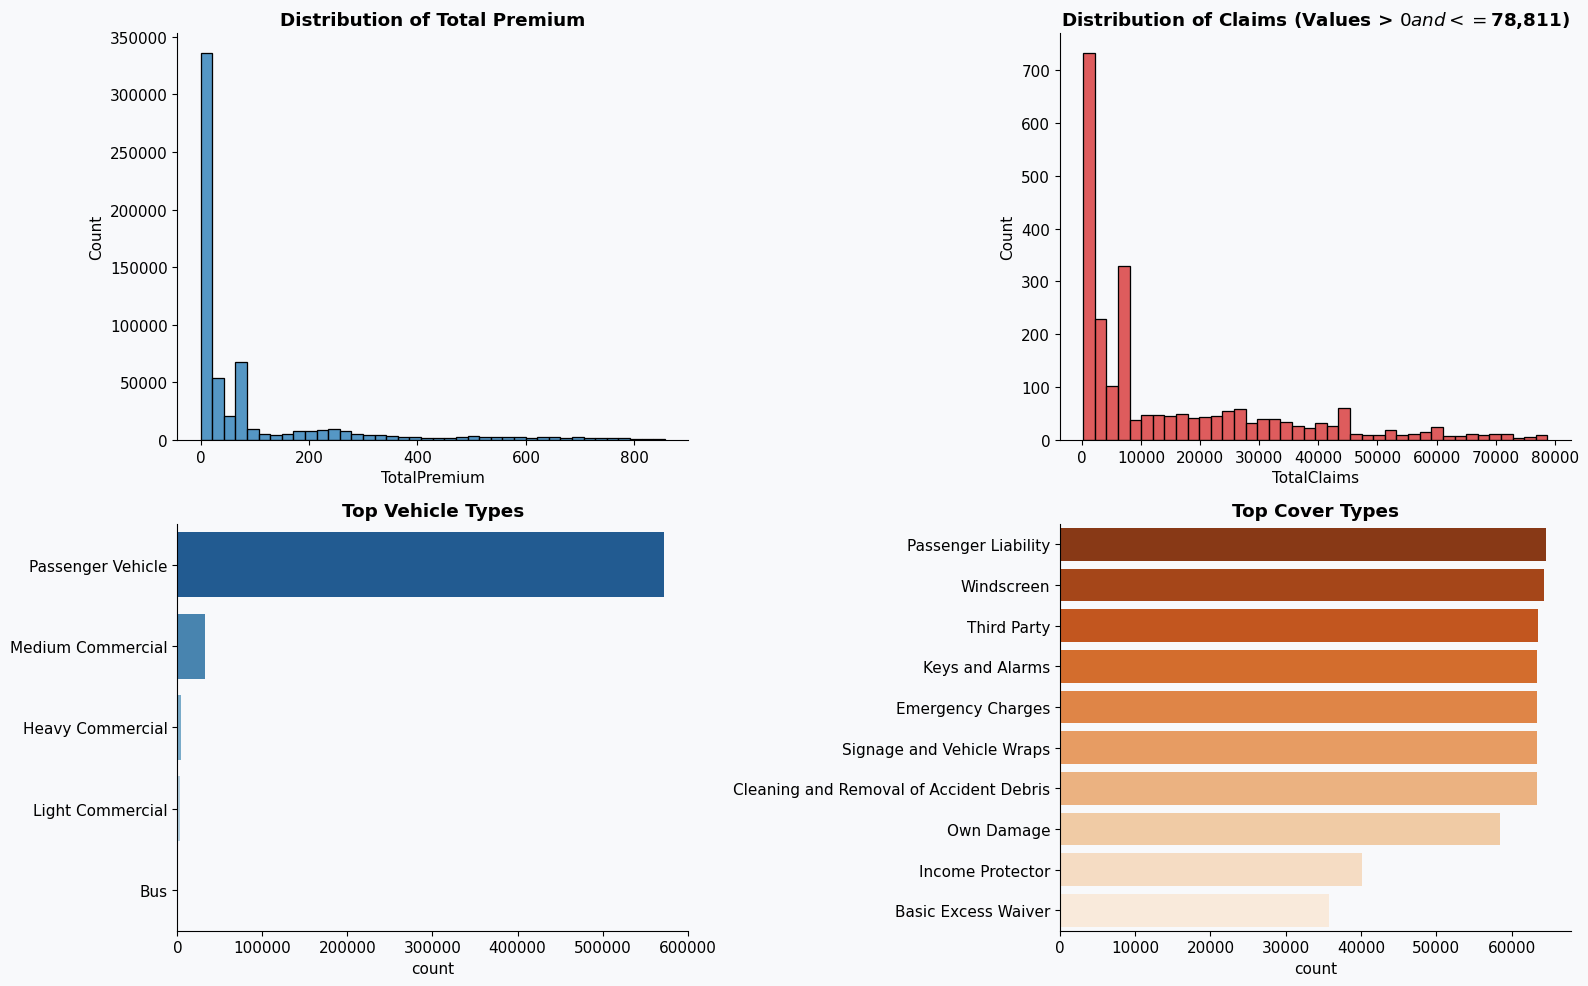

In [ ]:
# 2. Univariate Analysis -
plot_univariate_distributions(df_plot)


Bivariate / Multivariate Analysis 

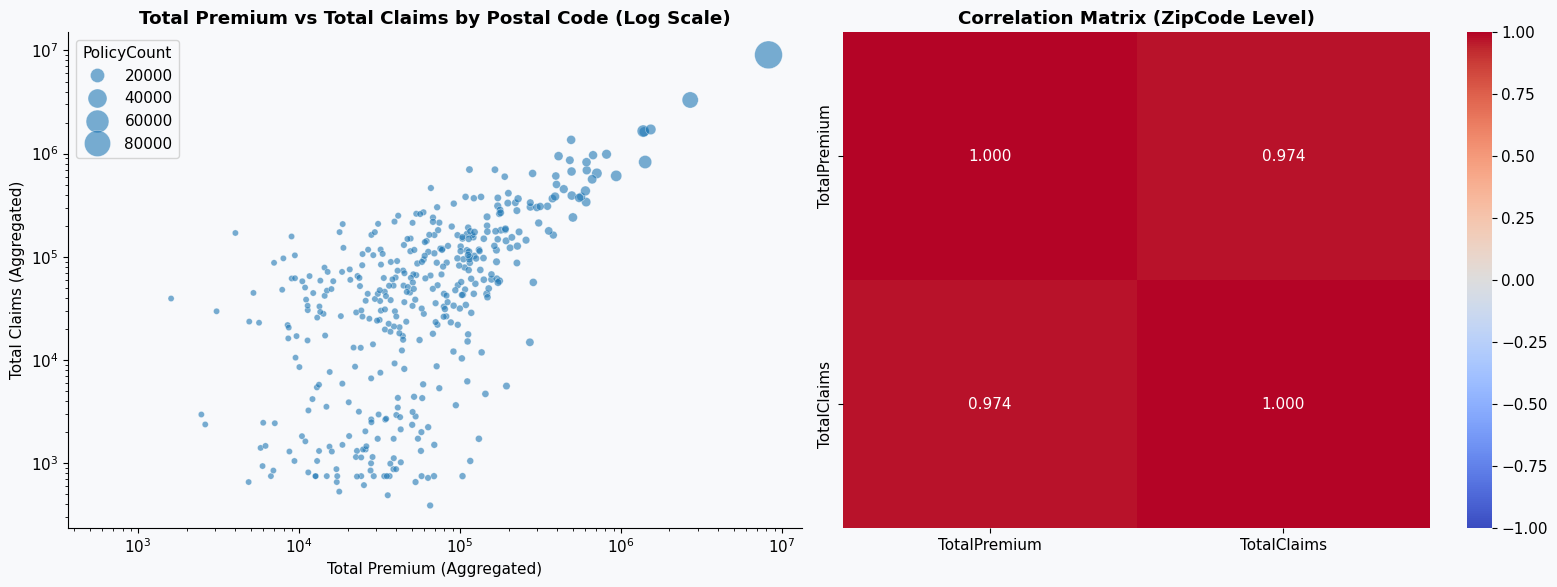

In [42]:
plot_premium_vs_claims(zip_summary)


Geographic Trends 

c:\Users\Hermela\Desktop\10academy\week3\src\visualizations.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  import matplotlib.pyplot as plt


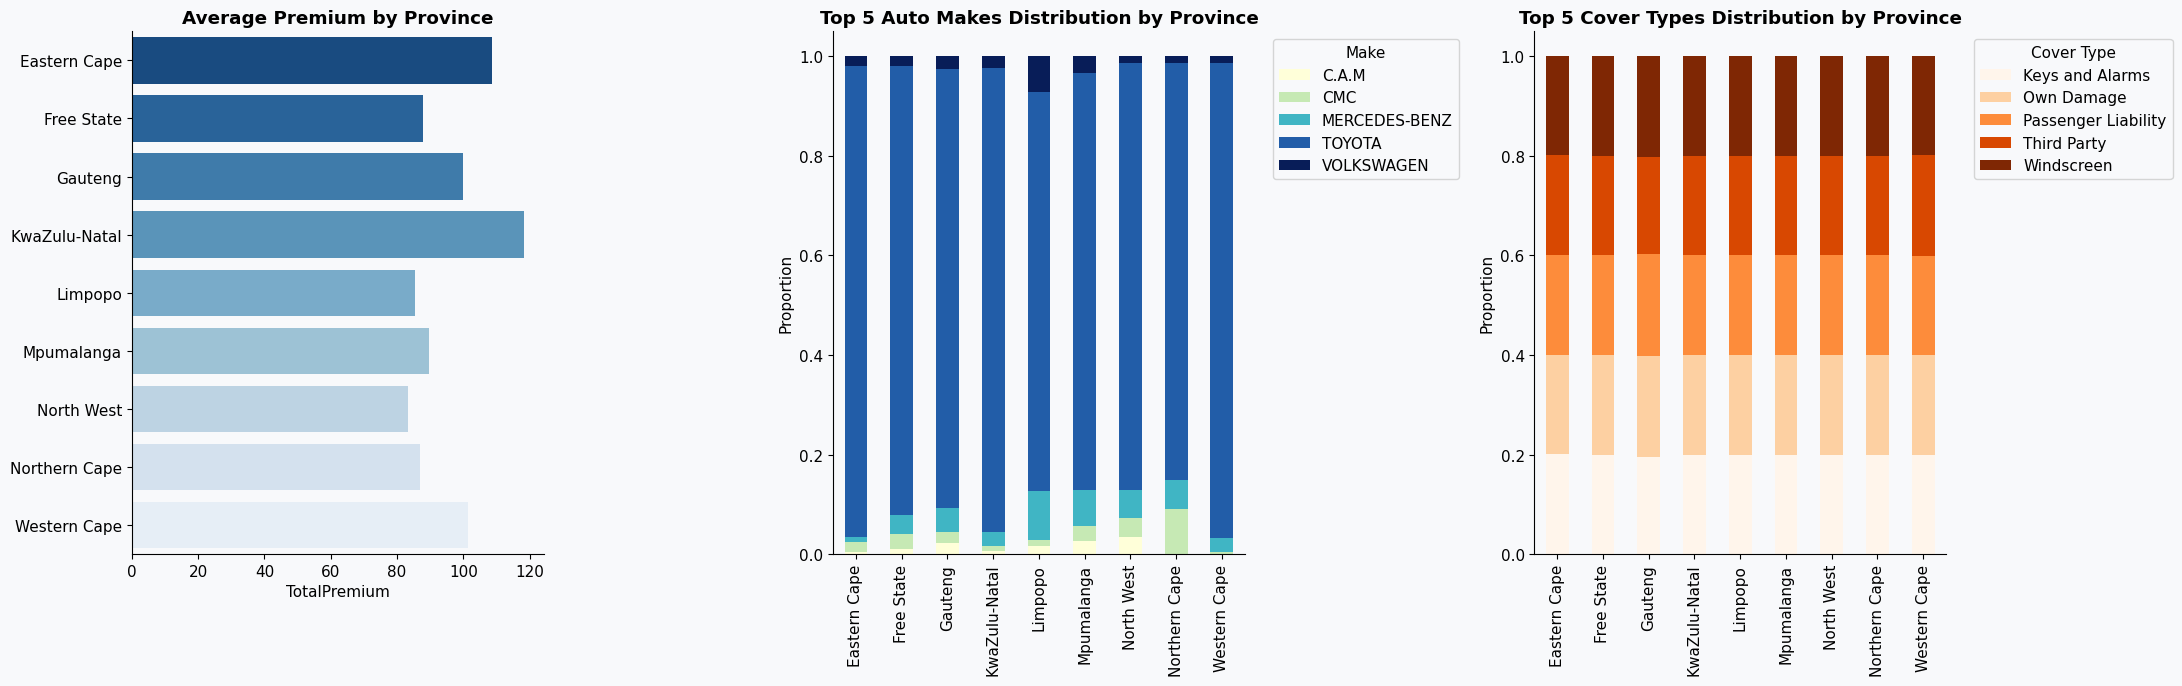

In [43]:
plot_province_risk(df_clean)


Outlier Detection

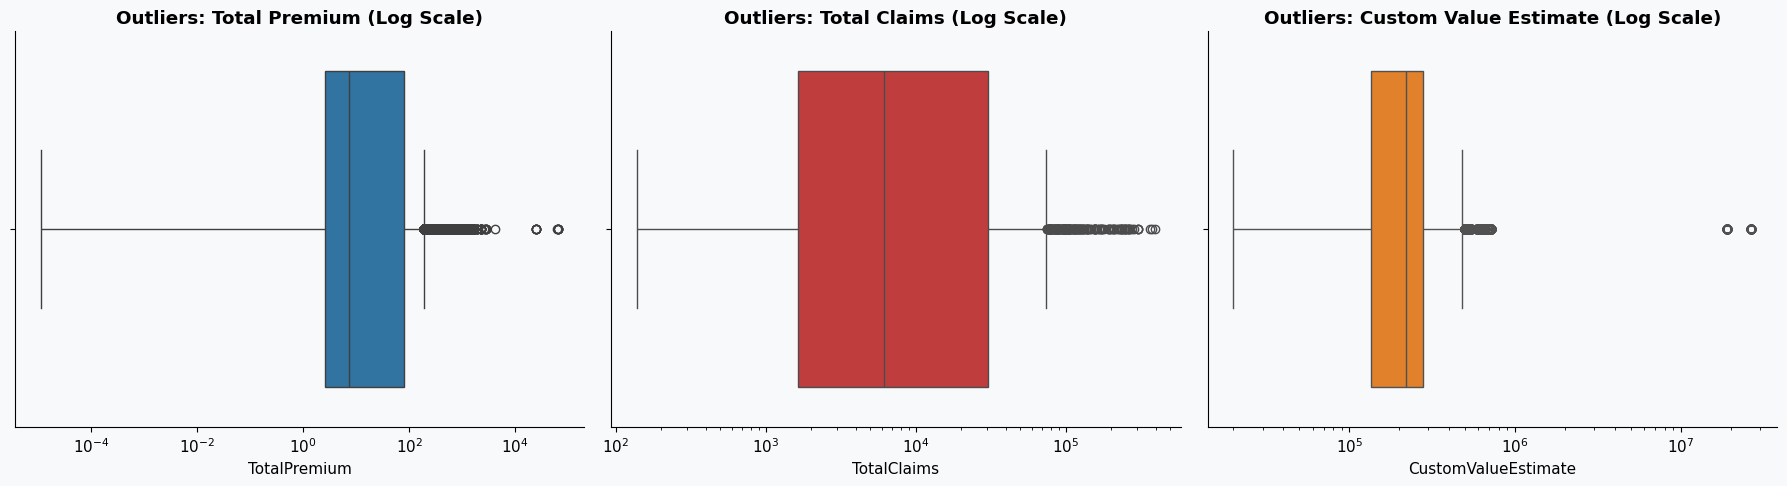

In [44]:
plot_outliers(df_clean)

<string>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



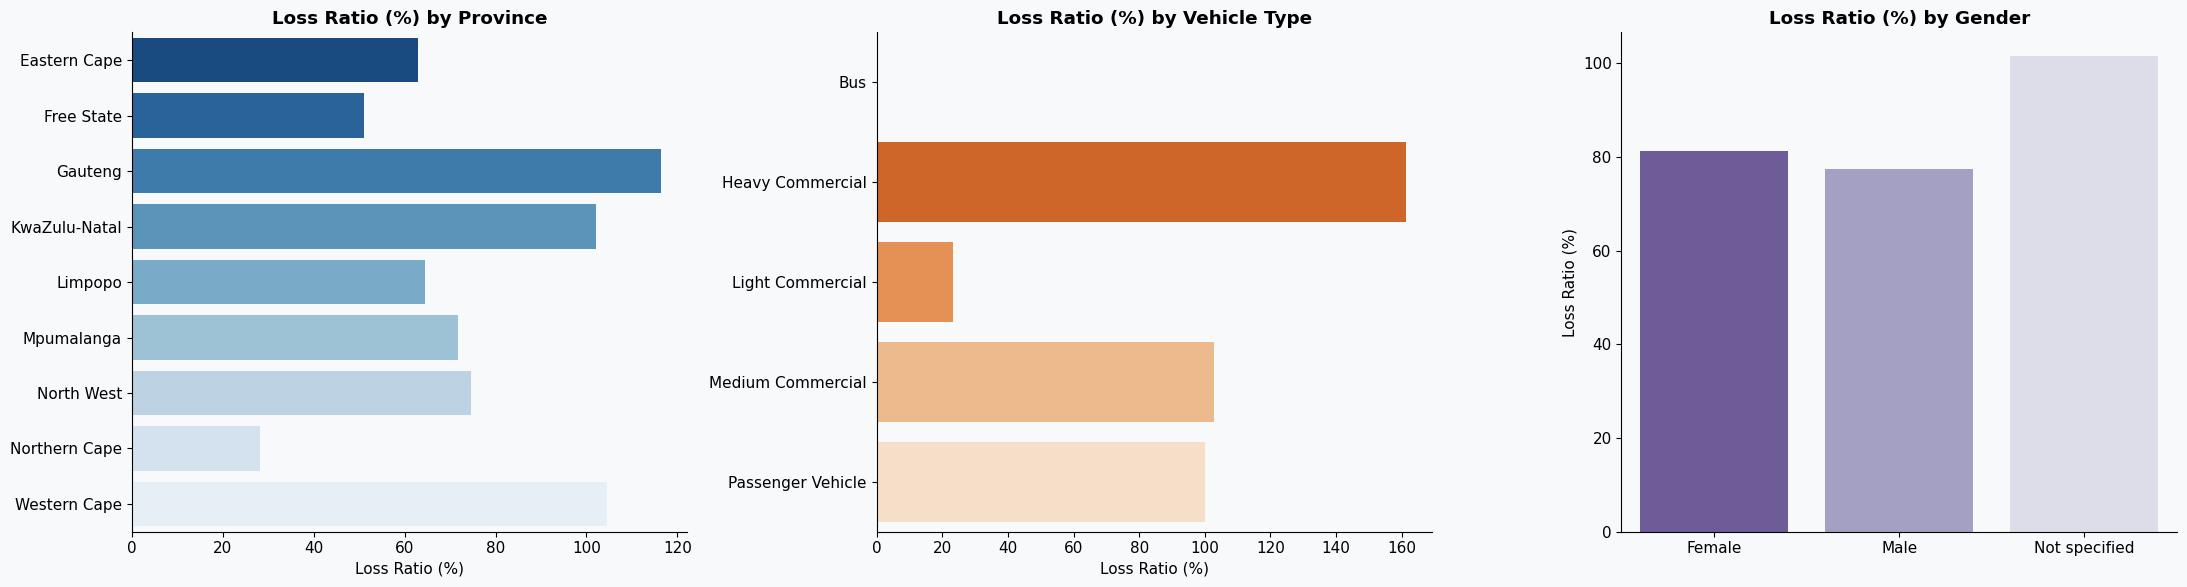

In [46]:
plot_loss_ratio(df_clean)


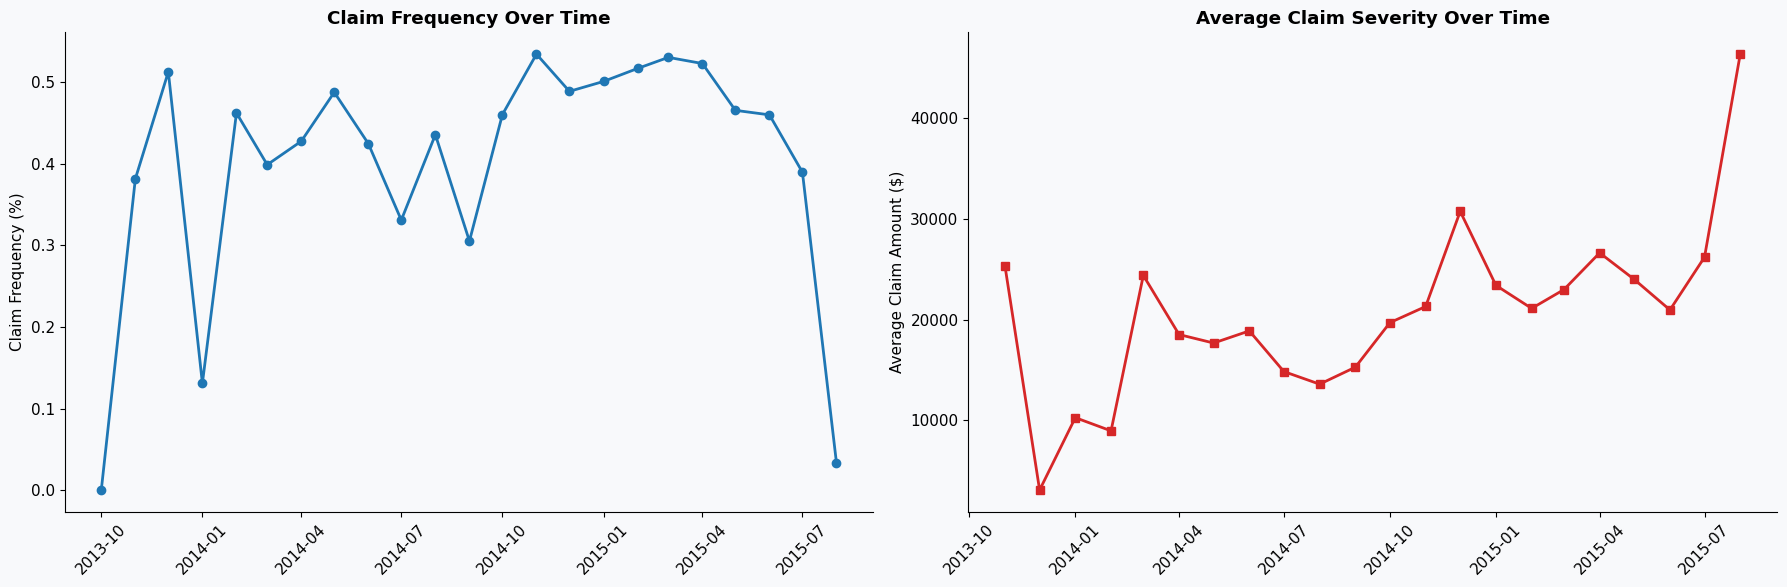

In [47]:
plot_temporal_trends(df_clean)


<string>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<string>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



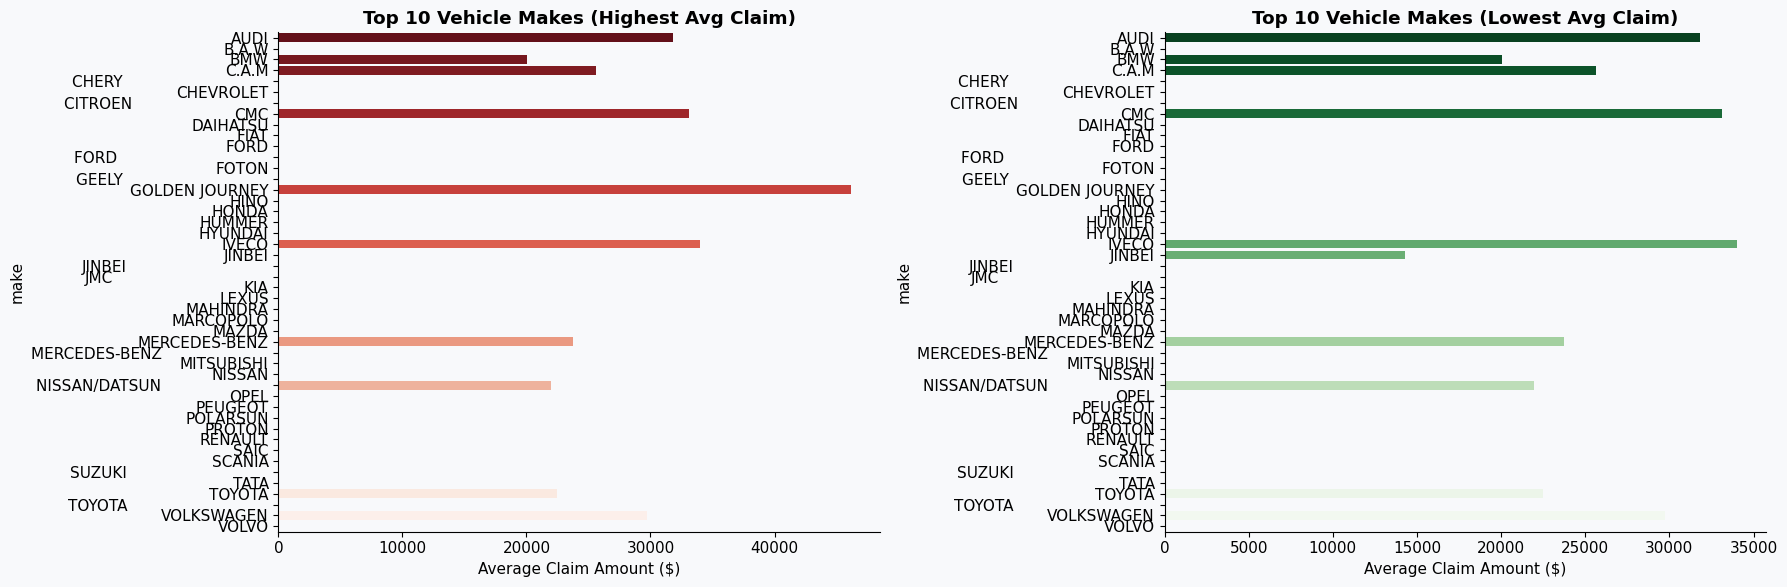

In [48]:
plot_vehicle_claims(df_clean)

1. Loss Ratios by Province, Vehicle Type, and Gender
What is happening?
The portfolio has critical profitability leaks.

Geography: Gauteng is operating at a severe loss with a Loss Ratio exceeding 110% (the company pays out more in claims than it collects in premiums). Western Cape and KwaZulu-Natal are also hovering at the unprofitability line (~100%).

Vehicle Type: Heavy Commercial vehicles are a massive financial drain, with a Loss Ratio soaring past 160%. Light Commercial vehicles, conversely, are highly profitable (Loss Ratio ~25%).

Gender: Policies where gender is "Not specified" are the worst performers (>100% Loss Ratio). Female policyholders have slightly higher loss ratios (~80%) than male policyholders (~77%).

Why is it happening?

Gauteng is highly urbanized with dense traffic, leading to more frequent and expensive accidents.

Heavy Commercial vehicles inherently cause catastrophic damage and carry higher liability when involved in collisions, easily wiping out the premiums collected.

The "Not specified" gender category is likely masking corporate, commercial, or fleet policies. Fleet drivers often exhibit different, riskier driving behaviors than private individuals because they do not own the vehicles they are driving.

What should we do about it?

Pricing Action: Immediately initiate a rate review to increase premiums for Heavy Commercial policies and policies located in Gauteng.

Underwriting Action: Audit the "Not specified" gender segment. If these are commercial fleets, move them to a stricter, fleet-specific pricing matrix rather than pooling them with standard individual policies.

2. Financial Distributions and Outliers
What is happening?
The portfolio relies heavily on high-volume, low-premium policies, but it is exposed to massive, right-skewed financial outliers. While most claims are relatively small, the log-scale box plots reveal a long tail of extreme claims stretching into the millions of dollars.

Why is it happening?
This is the fundamental nature of the insurance business model—thousands of safe policies fund the catastrophic losses of a few. However, the extreme spread in the CustomValueEstimate shows that the portfolio is mixing standard consumer vehicles with exceptionally high-value assets.

What should we do about it?

Risk Mitigation: Implement strict underwriting caps based on the CustomValueEstimate. For vehicles exceeding a specific valuation threshold (e.g., the 95th percentile), secure reinsurance to protect the company's balance sheet against million-dollar outlier claims.

3. Temporal Trends (18-Month Period)
What is happening?
Claim frequency remained relatively stable, oscillating largely between 0.3% and 0.5%. However, claim severity (the average cost of a claim) experienced a violent, unprecedented spike at the very end of the 18-month period, nearly doubling from ~$25,000 to over $45,000 in July 2015.

Why is it happening?
A sudden severity spike without a corresponding frequency spike typically points to high-impact external events. This could be a cluster of severe, multi-vehicle accidents involving commercial trucks (which we know are unprofitable), localized severe weather destroying high-value assets, or a sudden inflationary spike in parts/labor costs.

What should we do about it?

Investigation: The analytics team must drill down specifically into the claims filed in July 2015. Identify if these high-severity claims belong to a specific region (like Gauteng) or a specific vehicle type (Heavy Commercial).

Adjustment: Once the root cause of the July spike is identified, adjust predictive risk models to account for this localized or seasonal tail risk going forward.

4. Vehicle Makes and Claim Severity
What is happening?
Specialty and heavy commercial brands are driving the highest payouts. Golden Journey, IVECO, and CMC top the list, with average claims ranging from $30,000 to over $45,000. Conversely, standard consumer brands like Jinbei, BMW, Nissan, and Toyota generate the lowest average claims (under $25,000).

Why is it happening?
Commercial trucks (IVECO, Golden Journey) cause immense structural damage. On the other end, your stacked bar charts previously proved that Toyota holds an absolute monopoly (>80%) over this dataset. Because Toyota is the statistical "baseline" of your portfolio, its massive volume stabilizes its average claim cost, keeping it reliably low.

What should we do about it?

Segmentation: Create a distinct, higher-tier pricing matrix specifically for heavy commercial brands like IVECO and Golden Journey.

Retention Strategy: Leverage the high volume and predictable risk of Toyota data to offer highly competitive, granular pricing for Toyota drivers. Since they make up the vast majority of the portfolio and have lower average claims, retaining these customers is vital to keeping the portfolio afloat.